In [15]:
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit import transpile
from qiskit.circuit import Parameter
from qiskit.quantum_info import SparsePauliOp
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import EstimatorV2

In [16]:
backend = AerSimulator()

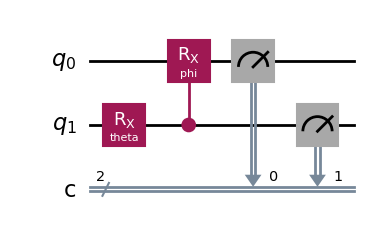

In [17]:
th = Parameter('theta')
ph = Parameter('phi')

qr = QuantumRegister(2,name='q')
cr = ClassicalRegister(2,name='c')

qc = QuantumCircuit(qr,cr)

qc.rx(th,1)
qc.crx(ph,1,0)
qc.measure(qr,cr)
qc.draw("mpl")

In [18]:
angles = [ [np.pi/3, np.pi/2], [np.pi/3, np.pi], [np.pi/2,np.pi] ] 

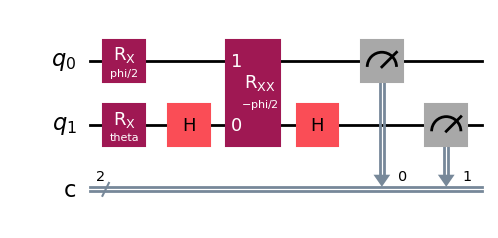

In [19]:
qct = transpile(qc,backend=backend)
qct.draw("mpl")

1. definir um backend
2. transpilar o circuito
3. instanciar o EstimatorV2
4. definir as observáveis
5. mapear o circuito no computador real (layout)
6. aplicar o layout às observáveis
7. executar o circuito 

In [20]:
estimator = EstimatorV2(mode=backend)

TypeError: EstimatorV2.__init__() got an unexpected keyword argument 'mode'

In [21]:
#Removendo as medidas dos circuitos
for i in range(len(qct.data)):
    print(i, qct.data[i].operation.name)

0 rx
1 rx
2 h
3 rxx
4 h
5 measure
6 measure


In [22]:
qct.data.pop(6)
qct.data.pop(5)

CircuitInstruction(operation=Instruction(name='measure', num_qubits=1, num_clbits=1, params=[]), qubits=(Qubit(QuantumRegister(2, 'q'), 0),), clbits=(Clbit(ClassicalRegister(2, 'c'), 0),))

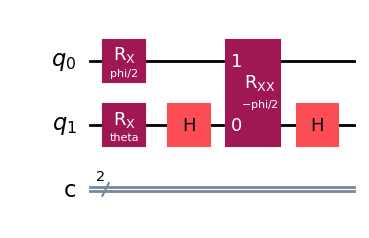

In [23]:
qct.draw("mpl")

In [24]:
obs = SparsePauliOp(["ZI", "IZ"], [0.5,0.5])

In [25]:
layout = qct.layout
obsF = obs.apply_layout(layout)

In [26]:
job = estimator.run([ (qct,obsF,angles,0.01) ])

NameError: name 'estimator' is not defined

In [27]:
valorE = job.result()[0].data.evs
print(valorE)

NameError: name 'job' is not defined